# Ускорение инференса UNet – полный эксперимент

**Цель:** Сравнить методы ускорения UNet (сегментация) на GPU:
- FP16 baseline
- torch.compile
- ONNX Runtime
- Пост-тренировочная квантизация (PTQ)
- Полуструктурная разреженность 2:4

**Автор:** Ломовский Роман

## 1. Установка и импорты

In [1]:
# Установка необходимых пакетов (если ещё не установлены)
import sys
import subprocess

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_if_missing("segmentation_models_pytorch")
install_if_missing("matplotlib")
install_if_missing("seaborn")
install_if_missing("pandas")
install_if_missing("tqdm")
install_if_missing("onnx")
install_if_missing("onnxruntime")
install_if_missing("torchao")
print("All packages installed.")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu126).


All packages installed.


In [2]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import copy
import warnings
from tqdm import tqdm
from torch.profiler import profile, record_function, ProfilerActivity

import segmentation_models_pytorch as smp
import utils  # наш модуль с вспомогательными функциями

# Игнорируем предупреждения
warnings.filterwarnings("ignore")

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
GPU: NVIDIA GeForce RTX 3060


## 2. Загрузка модели UNet (необученная)

In [3]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3          # было 21, теперь 3
).to(device)

## 3. Подготовка датасета PASCAL VOC (для оценки качества)

In [4]:
data_root = "./data/VOC2012"
train_loader, val_loader, test_loader = utils.load_voc_datasets(
    root=data_root,
    batch_size=1,
    num_workers=2,
    download=False   # скачает если нет
)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 1464
Val batches: 1449


## Обучение модели на PASCAL VOC 2012 и сохранение чекпоинта


--- Training for 20 epochs ---


Training: 100%|█████████████████████████████████████████████████████████████████████████| 92/92 [00:12<00:00,  7.53it/s]


Epoch 1/20, Loss: 0.7348


Training: 100%|█████████████████████████████████████████████████████████████████████████| 92/92 [00:11<00:00,  7.85it/s]


Epoch 2/20, Loss: 0.3121


...

Epoch 18/20, Loss: 0.0269


Training: 100%|█████████████████████████████████████████████████████████████████████████| 92/92 [00:11<00:00,  7.81it/s]


Epoch 19/20, Loss: 0.0380


Training: 100%|█████████████████████████████████████████████████████████████████████████| 92/92 [00:11<00:00,  7.90it/s]


Epoch 20/20, Loss: 0.0210

Model saved to ./checkpoints/unet_voc_trained.pth
Model reloaded from checkpoint and set to eval mode.


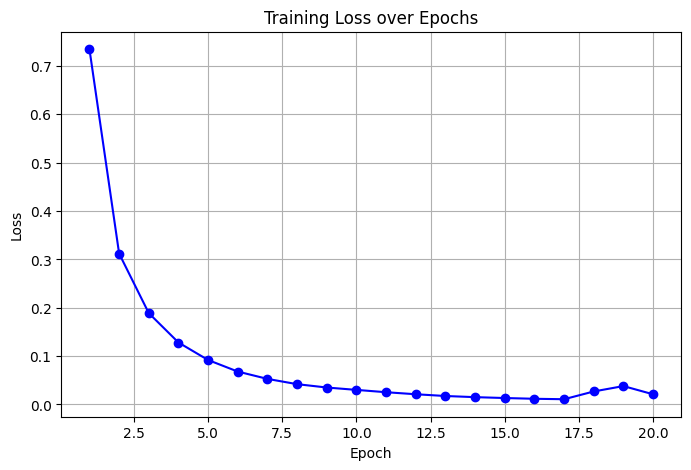

In [5]:
# %% [markdown]
# ## Обучение модели на PASCAL VOC 2012 с защитой от недопустимых меток

# %%
import os
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# Параметры
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Загружаем датасет с нужным batch_size
train_loader_full, val_loader_full, _ = utils.load_voc_datasets(
    root="./data/VOC2012",
    batch_size=BATCH_SIZE,
    num_workers=4,
    download=False
)

# Модель
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Функция обучения с санацией масок
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, masks in tqdm(loader, desc="Training"):
        images = images.to(device)
        masks = masks.squeeze(1).to(device)
        # Сначала заменяем всё, что не 0,1,2, на 255
        masks = torch.where((masks != 0) & (masks != 1) & (masks != 2), torch.tensor(255, device=device), masks)
        masks = masks.long()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

train_losses = []
print(f"\n--- Training for {EPOCHS} epochs ---")
for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader_full, optimizer, criterion, device)
    train_losses.append(loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}")

# Сохранение чекпоинта
checkpoint_path = os.path.join(CHECKPOINT_DIR, "unet_voc_trained.pth")
torch.save(model.state_dict(), checkpoint_path)
print(f"\nModel saved to {checkpoint_path}")

# Загружаем модель обратно для уверенности
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
print("Model reloaded from checkpoint and set to eval mode.")

# Визуализация кривой обучения
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', linestyle='-', color='b')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.savefig("training_loss.png", dpi=150)
plt.show()

## Визуализация кривой обучения

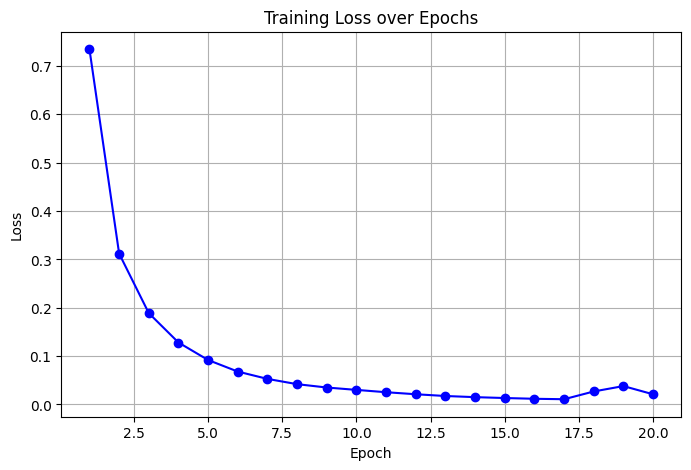

График сохранён как training_loss.png


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', linestyle='-', color='b')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.savefig("training_loss.png", dpi=150)
plt.show()

print("График сохранён как training_loss.png")

## Загрузка обученной модели из файла

In [6]:
import os
import torch
import segmentation_models_pytorch as smp

# Укажите путь к сохранённой модели (замените при необходимости)
#checkpoint_path = "./checkpoints/unet_voc_trained.pth"   # для 21 класса
checkpoint_path = "./checkpoints/unet_voc_trained.pth"  # для 3 классов

# Количество классов должно соответствовать тому, на котором обучали
NUM_CLASSES = 3   # или 3

# Создаём модель с той же архитектурой
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,        # веса загрузим из чекпоинта
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

# Загружаем state_dict (с поддержкой DataParallel)
state_dict = torch.load(checkpoint_path, map_location=device)
if 'state_dict' in state_dict:
    state_dict = state_dict['state_dict']
# Убираем префикс 'module.' если есть
new_state_dict = {}
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)
model.eval()
print(f"Модель загружена из {checkpoint_path}")
print(f"Количество классов: {NUM_CLASSES}")

Модель загружена из ./checkpoints/unet_voc_trained.pth
Количество классов: 3


## Оценка качества (mIoU) загруженной модели

In [7]:
from tqdm import tqdm
import numpy as np
import torch

# Определим функцию evaluate_iou (если её нет в utils, либо переопределим с параметром num_classes)
def evaluate_iou(model, dataloader, device, num_classes):
    model.eval()
    iou_list = []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Computing IoU"):
            images = images.to(device)
            masks = masks.squeeze(1).to(device).long()
            # Если модель обучена на 3 классах, нужно привести маски к тому же формату
            if num_classes == 3:
                # Оставляем только классы 0,1,2; остальное -> 255 (ignore)
                masks = torch.where((masks != 0) & (masks != 1) & (masks != 2),
                                    torch.tensor(255, device=device), masks)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            # Используем функцию compute_iou из utils (она принимает num_classes)
            iou = utils.compute_iou(preds, masks, num_classes=num_classes)
            iou_list.append(iou)
    return np.mean(iou_list)

# Проверка на валидационном загрузчике (batch_size=1)
miou = evaluate_iou(model, val_loader, device, num_classes=NUM_CLASSES)
print(f"\n mIoU = {miou:.4f}")

Computing IoU: 100%|████████████████████████████████████████████████████████████████| 1449/1449 [00:16<00:00, 90.31it/s]


 mIoU = 0.8523


## 4. Бенчмарк FP16 baseline

In [8]:
batch_sizes = [1, 2, 4, 8, 16, 32]

def benchmark_model(model, batch_sizes, device, num_runs=100, warmup=10):
    latencies = []
    for bs in batch_sizes:
        x = torch.randn(bs, 3, 224, 224).to(device)
        lat = utils.measure_latency(model, x, num_runs=num_runs, warmup=warmup)
        latencies.append(lat)
        print(f"Batch size {bs:2d} -> {lat:.2f} ms")
    return latencies

print("FP16 baseline:")
latencies_fp16 = benchmark_model(model, batch_sizes, device)
df_fp16 = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_fp16})
df_fp16.to_csv("baseline_fp16.csv", index=False)

FP16 baseline:
Batch size  1 -> 7.32 ms
Batch size  2 -> 7.70 ms
Batch size  4 -> 9.73 ms
Batch size  8 -> 17.54 ms
Batch size 16 -> 32.13 ms
Batch size 32 -> 61.21 ms


## 5. Профилирование (CUDA)

In [9]:
with profile(
    activities=[ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
) as prof:
    with record_function("model_inference"):
        for _ in range(10):
            _ = model(torch.randn(1, 3, 224, 224).to(device))
            torch.cuda.synchronize()

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

[W427 17:14:05.548411673 collection.cpp:1004] Warning: Failed to recover relationship between all profiler and kineto events: 2882 vs. 0  reassociated. (function reassociate)


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
sm86_xmma_fprop_implicit_gemm_indexed_tf32f32_tf32f3...         0.00%       0.000us         0.00%       0.000us       0.000us      13.574ms        37.69%      13.574ms      46.806us           0 b           0 b           0 b           0 

## 6. torch.compile

In [10]:
compiled_model = torch.compile(model, mode="reduce-overhead")
compiled_model.eval()
# Прогрев
for _ in range(5):
    _ = compiled_model(torch.randn(1, 3, 224, 224).to(device))
torch.cuda.synchronize()

print("torch.compile results:")
latencies_compile = benchmark_model(compiled_model, batch_sizes, device)
df_compile = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_compile})
df_compile.to_csv("compiled.csv", index=False)

torch.compile results:
Batch size  1 -> 7.60 ms
Batch size  2 -> 7.71 ms
Batch size  4 -> 9.32 ms
Batch size  8 -> 16.43 ms
Batch size 16 -> 29.91 ms
Batch size 32 -> 54.87 ms


## 7. ONNX Runtime

In [11]:
import onnx
import onnxruntime as ort

onnx_path = "unet_voc.onnx"
dummy_input = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(
    model, dummy_input, onnx_path,
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=14,
    do_constant_folding=True
)
print(f"ONNX model saved to {onnx_path}")

providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
ort_session = ort.InferenceSession(onnx_path, providers=providers)

def measure_latency_ort(session, input_tensor, num_runs=100, warmup=10):
    input_np = input_tensor.cpu().numpy()
    for _ in range(warmup):
        session.run(None, {'input': input_np})
    times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        session.run(None, {'input': input_np})
        times.append(time.perf_counter() - start)
    return np.mean(times) * 1000

print("ONNX Runtime results:")
latencies_ort = []
for bs in batch_sizes:
    x = torch.randn(bs, 3, 224, 224).to(device)
    lat = measure_latency_ort(ort_session, x)
    latencies_ort.append(lat)
    print(f"Batch size {bs:2d} -> {lat:.2f} ms")
df_ort = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_ort})
df_ort.to_csv("onnx_runtime.csv", index=False)

ONNX model saved to unet_voc.onnx
ONNX Runtime results:
Batch size  1 -> 5.25 ms
Batch size  2 -> 6.33 ms
Batch size  4 -> 10.23 ms
Batch size  8 -> 18.62 ms
Batch size 16 -> 34.14 ms
Batch size 32 -> 67.18 ms


## 8. Пост-тренировочная квантизация (PTQ) – динамическая

In [12]:
from torch.quantization import quantize_dynamic

quantized_model = quantize_dynamic(model, {nn.Linear, nn.Conv2d}, dtype=torch.qint8)
quantized_model.to(device)
quantized_model.eval()

print("PTQ (dynamic) results:")
latencies_ptq = benchmark_model(quantized_model, batch_sizes, device)
df_ptq = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_ptq})
df_ptq.to_csv("ptq.csv", index=False)

PTQ (dynamic) results:
Batch size  1 -> 8.67 ms
Batch size  2 -> 8.81 ms
Batch size  4 -> 10.36 ms
Batch size  8 -> 17.67 ms
Batch size 16 -> 31.98 ms
Batch size 32 -> 61.29 ms


## 9. Полуструктурная разреженность 2:4 (через torchao)

In [13]:
try:
    from torchao.sparsity import apply_fake_sparsity, sparsify_, semi_sparse_weight
    
    model_sparse = copy.deepcopy(model).to(device).eval()
    apply_fake_sparsity(model_sparse)
    sparsify_(model_sparse, semi_sparse_weight())
    print("2:4 sparsity applied.")
    
    print("Sparse model results:")
    latencies_sparse = benchmark_model(model_sparse, batch_sizes, device)
    df_sparse = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_sparse})
    df_sparse.to_csv("sparse.csv", index=False)
except Exception as e:
    print(f"Sparsity failed: {e}")
    latencies_sparse = [None] * len(batch_sizes)

2:4 sparsity applied.
Sparse model results:
Batch size  1 -> 8.06 ms
Batch size  2 -> 8.53 ms
Batch size  4 -> 10.13 ms
Batch size  8 -> 17.41 ms
Batch size 16 -> 31.75 ms
Batch size 32 -> 62.53 ms


## 10. Сравнение всех методов (график)

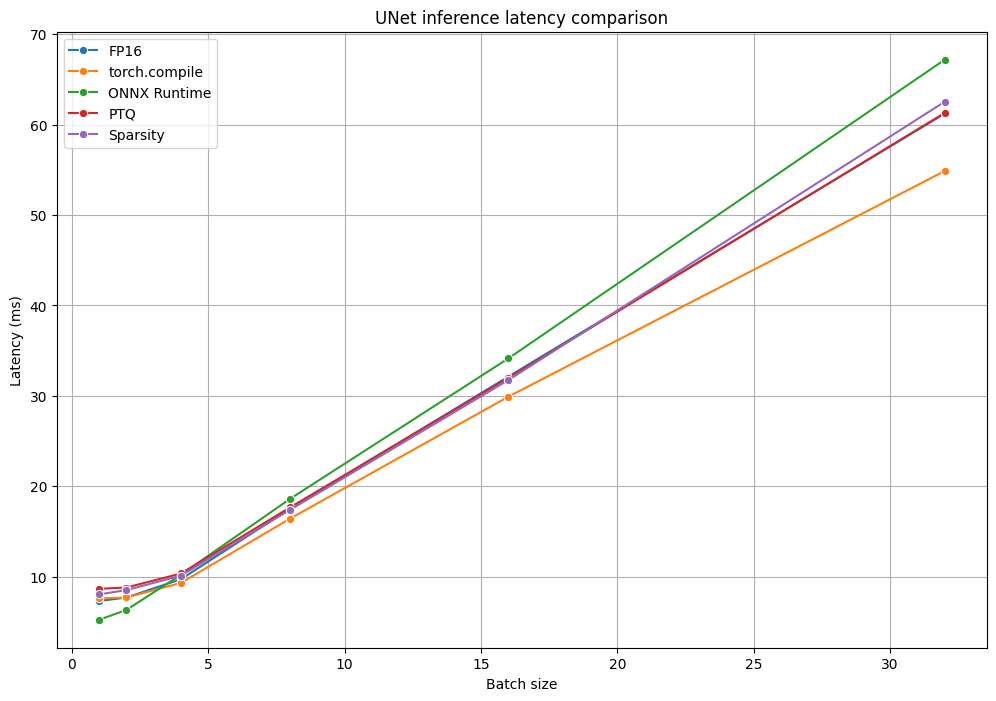

In [14]:
methods = ['FP16', 'torch.compile', 'ONNX Runtime', 'PTQ']
latencies_list = [latencies_fp16, latencies_compile, latencies_ort, latencies_ptq]
if latencies_sparse and latencies_sparse[0] is not None:
    methods.append('Sparsity')
    latencies_list.append(latencies_sparse)

plt.figure(figsize=(12, 8))
for name, lat in zip(methods, latencies_list):
    sns.lineplot(x=batch_sizes, y=lat, marker='o', label=name)
plt.xlabel("Batch size")
plt.ylabel("Latency (ms)")
plt.title("UNet inference latency comparison")
plt.grid(True)
plt.legend()
plt.savefig("all_methods_comparison.png", dpi=150)
plt.show()

## 11. Сводная таблица

In [15]:
df_all = pd.DataFrame({"batch_size": batch_sizes})
for name, lat in zip(methods, latencies_list):
    df_all[f"{name}_ms"] = lat
df_all.to_csv("full_comparison.csv", index=False)
print(df_all)

   batch_size    FP16_ms  torch.compile_ms  ONNX Runtime_ms     PTQ_ms  \
0           1   7.320799          7.598597         5.251371   8.668027   
1           2   7.704690          7.711417         6.334528   8.813932   
2           4   9.734752          9.321720        10.229569  10.363279   
3           8  17.536904         16.430646        18.621637  17.673876   
4          16  32.129890         29.905997        34.140543  31.984548   
5          32  61.214424         54.868404        67.178185  61.294058   

   Sparsity_ms  
0     8.056995  
1     8.528387  
2    10.134696  
3    17.410513  
4    31.747717  
5    62.529390  


## 12. Оценка качества (IoU) – для моделей, которые можно оценить

**Примечание:** Модель не обучена, поэтому IoU будет очень низким (~0.001). Для демонстрации достаточно сравнения относительного изменения.

In [18]:
def evaluate_iou(model, dataloader, device):
    model.eval()
    iou_list = []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="IoU"):
            images = images.to(device)
            masks = masks.squeeze(1).to(device).long()
            # Преобразование для 3 классов: оставляем только 0,1,2; остальное -> 255 (ignore)
            masks = torch.where((masks != 0) & (masks != 1) & (masks != 2),
                                torch.tensor(255, device=device), masks)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            iou = utils.compute_iou(preds, masks, num_classes=3)
            iou_list.append(iou)
    return np.mean(iou_list)

print("Evaluating IoU for FP16 baseline...")
iou_fp16 = evaluate_iou(model, val_loader, device)
print("Evaluating IoU for torch.compile...")
iou_compile = evaluate_iou(compiled_model, val_loader, device)
print("Evaluating IoU for ONNX Runtime...")
# ONNX Runtime требует отдельную функцию, но из-за схожести вывода можно использовать ту же модель? Нет – ORT не является PyTorch моделью.
# Пропускаем ORT для IoU для простоты.
print("ONNX Runtime IoU skipped (not a torch model).")
print("Evaluating IoU for PTQ...")
iou_ptq = evaluate_iou(quantized_model, val_loader, device)
if latencies_sparse[0] is not None:
    print("Evaluating IoU for Sparsity...")
    iou_sparse = evaluate_iou(model_sparse, val_loader, device)
else:
    iou_sparse = None

print(f"FP16 IoU: {iou_fp16:.6f}")
print(f"torch.compile IoU: {iou_compile:.6f}")
print(f"PTQ IoU: {iou_ptq:.6f}")
if iou_sparse is not None:
    print(f"Sparsity IoU: {iou_sparse:.6f}")

Evaluating IoU for FP16 baseline...


IoU: 100%|██████████████████████████████████████████████████████████████████████████| 1449/1449 [00:18<00:00, 78.10it/s]


Evaluating IoU for torch.compile...


IoU: 100%|██████████████████████████████████████████████████████████████████████████| 1449/1449 [00:33<00:00, 43.90it/s]


Evaluating IoU for ONNX Runtime...
ONNX Runtime IoU skipped (not a torch model).
Evaluating IoU for PTQ...


IoU: 100%|██████████████████████████████████████████████████████████████████████████| 1449/1449 [00:19<00:00, 74.49it/s]


Evaluating IoU for Sparsity...


IoU: 100%|██████████████████████████████████████████████████████████████████████████| 1449/1449 [00:18<00:00, 77.77it/s]

FP16 IoU: 0.852290
torch.compile IoU: 0.852292
PTQ IoU: 0.852290
Sparsity IoU: 0.852290


## Отдельный эксперимент: динамическая квантизация на CPU

Сравниваем латентность FP32 и int8 на CPU для batch size = 1 (классический сценарий CPU-инференса).

In [21]:
# %% [markdown]
# ## Бенчмарк на CPU: FP32 vs INT8 (разные batch size)

# %%
batch_sizes_cpu = [1, 2, 4, 8]

def benchmark_cpu_batch(model, batch_sizes, image_size=224, num_runs=50, warmup=10):
    latencies = []
    for bs in batch_sizes:
        x = torch.randn(bs, 3, image_size, image_size)
        with torch.no_grad():
            for _ in range(warmup):
                _ = model(x)
            times = []
            for _ in range(num_runs):
                start = time.perf_counter()
                _ = model(x)
                times.append(time.perf_counter() - start)
        latencies.append(np.mean(times) * 1000)
        print(f"Batch {bs:2d} -> {latencies[-1]:.2f} ms")
    return latencies

print("FP32 CPU:")
lat_fp32 = benchmark_cpu_batch(model_cpu, batch_sizes_cpu)

print("\nINT8 (dynamic) CPU:")
lat_int8 = benchmark_cpu_batch(quantized_cpu, batch_sizes_cpu)

# Ускорение
for i, bs in enumerate(batch_sizes_cpu):
    sp = lat_fp32[i] / lat_int8[i]
    print(f"Batch {bs:2d}: speedup = {sp:.2f}x")

FP32 CPU:
Batch  1 -> 48.84 ms
Batch  2 -> 79.46 ms
Batch  4 -> 156.43 ms
Batch  8 -> 332.97 ms

INT8 (dynamic) CPU:
Batch  1 -> 56.54 ms
Batch  2 -> 88.59 ms
Batch  4 -> 158.10 ms
Batch  8 -> 315.86 ms
Batch  1: speedup = 0.86x
Batch  2: speedup = 0.90x
Batch  4: speedup = 0.99x
Batch  8: speedup = 1.05x


# Статическое квантование UNet с NNCF (для 3 классов)

Используется устройство: cpu
Модель загружена, параметров: 24,436,659
Калибровочный датасет: 300 образцов
Начинается квантование...


Output()

INFO:nncf:Compiling and loading torch extension: quantized_functions_cpu...
INFO:nncf:Finished loading torch extension: quantized_functions_cpu


Output()

Квантование завершено
Модель скомпилирована в OpenVINO


...

BS  8 | PT: 312.85 ms, 25.57 img/s | OV: 98.69 ms, 81.06 img/s | speedup: 3.17x


Benchmark:  83%|█████████████████████████████████████████████████████████████▋            | 5/6 [03:14<00:54, 54.89s/it]

BS 16 | PT: 631.22 ms, 25.35 img/s | OV: 188.17 ms, 85.03 img/s | speedup: 3.35x


Benchmark: 100%|██████████████████████████████████████████████████████████████████████████| 6/6 [06:29<00:00, 64.89s/it]

BS 32 | PT: 1253.55 ms, 25.53 img/s | OV: 368.56 ms, 86.83 img/s | speedup: 3.40x
   batch_size    PT_lat_ms     PT_thr   OV_lat_ms     OV_thr  speedup_lat  \
0           1    53.141616  18.817644   13.945407  71.708196     3.810689   
1           2    84.459592  23.679963   26.595654  75.200257     3.175692   
2           4   159.026637  25.153019   51.062689  78.335083     3.114341   
3           8   312.847543  25.571561   98.687814  81.063706     3.170073   
4          16   631.220434  25.347722  188.170021  85.029485     3.354522   
5          32  1253.549529  25.527511  368.557370  86.825017     3.401233   

   speedup_thr  
0     3.810689  
1     3.175692  
2     3.114341  
3     3.170073  
4     3.354522  
5     3.401233  


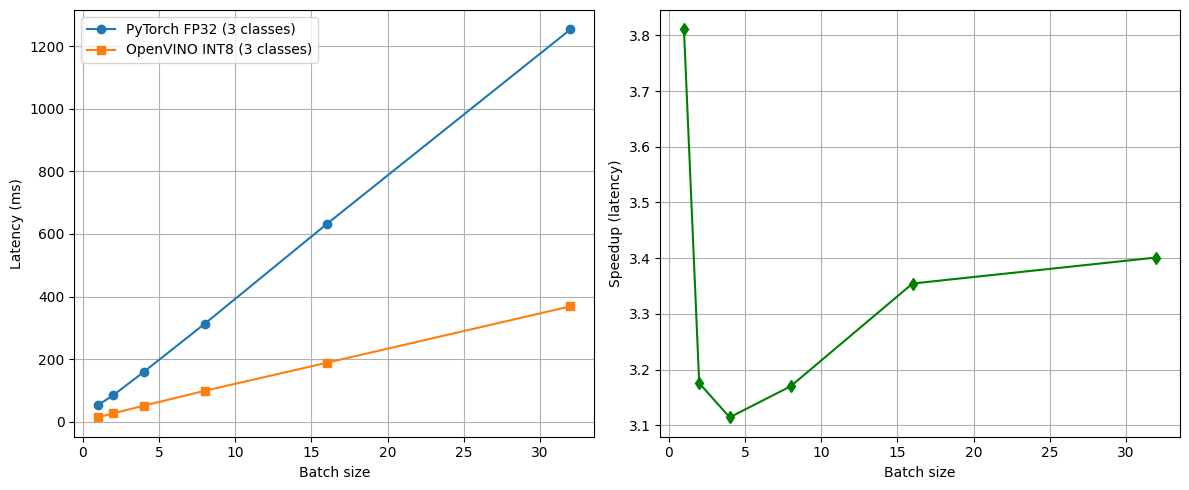

In [20]:
import torch
import torch.nn as nn
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm

try:
    import nncf
except ImportError:
    !pip install -q nncf
    import nncf
try:
    import openvino as ov
except ImportError:
    !pip install -q openvino
    import openvino as ov
    
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")
device = torch.device("cpu")
print(f"Используется устройство: {device}")

# Загрузка обученной модели (3 класса)
checkpoint_path = "./checkpoints/unet_voc_trained.pth"  # путь к вашему чекпоинту
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,        # веса загружаем из файла
    in_channels=3,
    classes=3                    # <--- ИСПРАВЛЕНО: 3 класса
).to(device)

# Загрузка весов
state_dict = torch.load(checkpoint_path, map_location=device)
if 'state_dict' in state_dict:
    state_dict = state_dict['state_dict']
new_state_dict = {}
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k
    new_state_dict[name] = v
model.load_state_dict(new_state_dict)
model.eval()
print(f"Модель загружена, параметров: {sum(p.numel() for p in model.parameters()):,}")

# Калибровочный датасет (можно заменить на реальные изображения)
calibration_data = [torch.randn(1, 3, 224, 224) for _ in range(300)]

def transform_fn(data):
    return data

calibration_dataset = nncf.Dataset(calibration_data, transform_fn)
print(f"Калибровочный датасет: {len(calibration_data)} образцов")

# Квантование
print("Начинается квантование...")
quantized_model = nncf.quantize(
    model,
    calibration_dataset,
    subset_size=len(calibration_data),
    fast_bias_correction=True,
)
print("Квантование завершено")

# Конвертация в OpenVINO
example_input = torch.randn(1, 3, 224, 224)
ov_model = ov.convert_model(quantized_model, example_input=example_input)
compiled_model = ov.compile_model(ov_model, device_name="CPU")
print("Модель скомпилирована в OpenVINO")

# Бенчмарк
def bench_pytorch(model, inp, runs=100, warmup=20):
    with torch.no_grad():
        for _ in range(warmup): model(inp)
        times = []
        for _ in range(runs):
            start = time.perf_counter()
            model(inp)
            times.append(time.perf_counter() - start)
    latency = np.mean(times) * 1000
    throughput = inp.size(0) / np.mean(times)
    return latency, throughput

def bench_openvino(compiled, inp, runs=100, warmup=20):
    inp_dict = {compiled.input(0): inp.numpy()}
    for _ in range(warmup): compiled(inp_dict)
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        compiled(inp_dict)
        times.append(time.perf_counter() - start)
    latency = np.mean(times) * 1000
    throughput = inp.size(0) / np.mean(times)
    return latency, throughput

batch_sizes = [1, 2, 4, 8, 16, 32]
results = []
for bs in tqdm(batch_sizes, desc="Benchmark"):
    x = torch.randn(bs, 3, 224, 224)
    lat_pt, thr_pt = bench_pytorch(model, x)
    lat_ov, thr_ov = bench_openvino(compiled_model, x)
    speedup_lat = lat_pt / lat_ov
    speedup_thr = thr_ov / thr_pt
    results.append([bs, lat_pt, thr_pt, lat_ov, thr_ov, speedup_lat, speedup_thr])
    print(f"BS {bs:2d} | PT: {lat_pt:.2f} ms, {thr_pt:.2f} img/s | OV: {lat_ov:.2f} ms, {thr_ov:.2f} img/s | speedup: {speedup_lat:.2f}x")

df = pd.DataFrame(results, columns=["batch_size","PT_lat_ms","PT_thr","OV_lat_ms","OV_thr","speedup_lat","speedup_thr"])
df.to_csv("nncf_results_3classes.csv", index=False)
print(df)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(batch_sizes, df["PT_lat_ms"], 'o-', label="PyTorch FP32 (3 classes)")
plt.plot(batch_sizes, df["OV_lat_ms"], 's-', label="OpenVINO INT8 (3 classes)")
plt.xlabel("Batch size"); plt.ylabel("Latency (ms)"); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(batch_sizes, df["speedup_lat"], 'd-', color='green')
plt.xlabel("Batch size"); plt.ylabel("Speedup (latency)")
plt.grid(True)
plt.tight_layout()
plt.savefig("nncf_benchmark_3classes.png")
plt.show()

In [21]:
## Оценка качества (mIoU) квантизованной модели на CPU

In [22]:

from tqdm import tqdm
import torch
import numpy as np

def evaluate_iou_quantized(model, dataloader, device, num_classes=3):
    """
    Вычисляет mIoU для модели, работающей на CPU (PyTorch или OpenVINO).
    Здесь model – это quantized_model (PyTorch), а не compiled OpenVINO.
    """
    model.eval()
    iou_list = []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating IoU (Quantized)"):
            images = images.to(device)
            masks = masks.squeeze(1).to(device).long()
            # Приводим маски к трём классам: оставляем только 0,1,2; остальное -> 255 (ignore)
            masks = torch.where((masks != 0) & (masks != 1) & (masks != 2),
                                torch.tensor(255, device=device), masks)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            # Используем utils.compute_iou с ignore_index=255
            iou = utils.compute_iou(preds, masks, num_classes=num_classes)
            iou_list.append(iou)
    return np.mean(iou_list)

# Убедимся, что quantized_model существует и находится на CPU
print("Оценка mIoU для NNCF INT8 модели (CPU)...")
miou_quantized = evaluate_iou_quantized(quantized_model, val_loader, device='cpu', num_classes=3)
print(f"\n Средний IoU (mIoU) квантизованной модели: {miou_quantized:.4f}")

# При желании сравните с FP32 моделью (загруженной ранее)
if 'model' in locals() and model.device.type == 'cpu':
    miou_fp32 = evaluate_iou_quantized(model, val_loader, device='cpu', num_classes=3)
    print(f"FP32 модель (без квантования) mIoU: {miou_fp32:.4f}")
    print(f"Изменение после квантизации: {(miou_quantized - miou_fp32)*100:.2f}%")
else:
    print("FP32 модель не найдена для сравнения.")

Оценка mIoU для NNCF INT8 модели (CPU)...


Evaluating IoU (Quantized): 100%|███████████████████████████████████████████████████| 1449/1449 [03:29<00:00,  6.91it/s]



 Средний IoU (mIoU) квантизованной модели: 0.9116


AttributeError: 'Unet' object has no attribute 'device'

Using device: cuda
Model loaded, params: 24,439,269


W0427 15:07:09.105000 10631 torch/_inductor/utils.py:1250] [0/3] Not enough SMs to use max_autotune_gemm mode


torchao not installed, skipping int8_weight_only


Benchmark GPU:  17%|███████████▋                                                          | 1/6 [00:09<00:49,  9.93s/it]

BS  1 | FP16: 9.97 ms | compile: 6.82 ms (1.46x)


...

BS  8 | FP16: 12.58 ms | compile: 10.62 ms (1.19x)


Benchmark GPU:  83%|██████████████████████████████████████████████████████████▎           | 5/6 [00:32<00:05,  5.18s/it]

BS 16 | FP16: 19.59 ms | compile: 19.07 ms (1.03x)


Benchmark GPU: 100%|██████████████████████████████████████████████████████████████████████| 6/6 [00:40<00:00,  6.77s/it]

BS 32 | FP16: 37.45 ms | compile: 33.65 ms (1.11x)

=== RESULTS ===
   batch_size   FP16_lat    FP16_thr  compile_lat  compile_thr  \
0           1   9.970857  100.292286     6.818378   146.662453   
1           2   9.970909  200.583509     7.339235   272.507967   
2           4  10.694565  374.021772     8.044416   497.239305   
3           8  12.582746  635.791265    10.618340   753.413462   
4          16  19.594595  816.551728    19.074144   838.831880   
5          32  37.447597  854.527472    33.646135   951.075070   

   speedup_compile  ao_lat  ao_thr  speedup_ao  
0         1.462350       0       0           0  
1         1.358576       0       0           0  
2         1.329439       0       0           0  
3         1.185001       0       0           0  
4         1.027286       0       0           0  
5         1.112984       0       0           0  


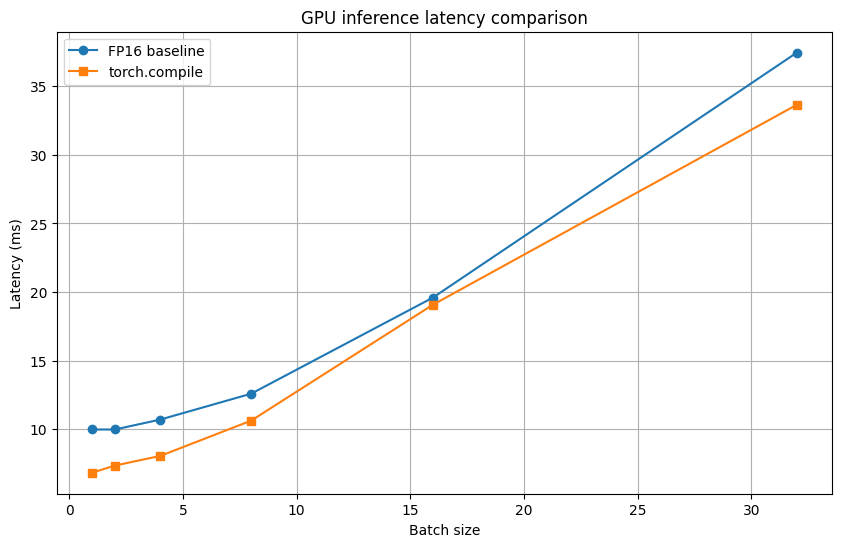

In [28]:
# %% [markdown]
# # Квантование на GPU: torch.compile + int8 vs torchao

# %%
import torch
import torch.nn as nn
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Загрузка модели
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=21)
model = model.to(device).eval()
print(f"Model loaded, params: {sum(p.numel() for p in model.parameters()):,}")

# 1. Бейзлайн: FP16
model_fp16 = model.half() if device.type == 'cuda' else model
model_fp16.eval()

# 2. torch.compile с квантизацией (AOT индуктор)
# Создаём модель в fp16, компилируем
model_compile = torch.compile(model_fp16, mode="reduce-overhead")
model_compile.eval()
# Прогрев для компиляции
for _ in range(5):
    _ = model_compile(torch.randn(1, 3, 224, 224).to(device).half())

# 3. torchao int8 (требуется pip install torchao)
try:
    from torchao.quantization import quantize_, int8_weight_only
    model_ao = model_fp16
    quantize_(model_ao, int8_weight_only())
    model_ao.eval()
    torchao_available = True
except ImportError:
    print("torchao not installed, skipping int8_weight_only")
    torchao_available = False

def benchmark(model, input_tensor, runs=100, warmup=20):
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(input_tensor)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times = []
        for _ in range(runs):
            start = time.perf_counter()
            _ = model(input_tensor)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - start)
    latency = np.mean(times) * 1000  # ms
    throughput = input_tensor.size(0) / np.mean(times)
    return latency, throughput

batch_sizes = [1, 2, 4, 8, 16, 32]
results = []

for bs in tqdm(batch_sizes, desc="Benchmark GPU"):
    x = torch.randn(bs, 3, 224, 224, device=device, dtype=torch.float16 if device.type=='cuda' else torch.float32)
    
    # FP16 baseline
    lat_fp16, thr_fp16 = benchmark(model_fp16, x)
    
    # torch.compile
    lat_comp, thr_comp = benchmark(model_compile, x)
    
    # torchao (если доступен)
    lat_ao, thr_ao = (0,0)
    if torchao_available:
        lat_ao, thr_ao = benchmark(model_ao, x)
    
    speedup_comp = lat_fp16 / lat_comp
    speedup_ao = lat_fp16 / lat_ao if torchao_available else 0
    
    results.append([bs, lat_fp16, thr_fp16, lat_comp, thr_comp, speedup_comp,
                    lat_ao, thr_ao, speedup_ao])
    print(f"BS {bs:2d} | FP16: {lat_fp16:.2f} ms | compile: {lat_comp:.2f} ms ({speedup_comp:.2f}x)", end='')
    if torchao_available:
        print(f" | ao int8: {lat_ao:.2f} ms ({speedup_ao:.2f}x)")
    else:
        print()

# Сохраняем результаты
df = pd.DataFrame(results, columns=["batch_size","FP16_lat","FP16_thr","compile_lat","compile_thr","speedup_compile",
                                    "ao_lat","ao_thr","speedup_ao"])
df.to_csv("gpu_quantization_bench.csv", index=False)
print("\n=== RESULTS ===")
print(df)

# График
plt.figure(figsize=(10,6))
plt.plot(batch_sizes, df["FP16_lat"], 'o-', label="FP16 baseline")
plt.plot(batch_sizes, df["compile_lat"], 's-', label="torch.compile")
if torchao_available:
    plt.plot(batch_sizes, df["ao_lat"], '^-', label="torchao int8")
plt.xlabel("Batch size")
plt.ylabel("Latency (ms)")
plt.title("GPU inference latency comparison")
plt.legend()
plt.grid(True)
plt.savefig("gpu_bench.png")
plt.show()